<a href="https://colab.research.google.com/github/ashivashankars/CMPE258_Assignments/blob/main/19_custom_activations_etc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 19 — Custom Activation, Initializer, Regularizer & Constraint

## What This Notebook Covers
This notebook builds every low-level customizable component of a Keras/PyTorch
layer from scratch, following Géron's Hands-On ML Chapter 12 patterns.

**Components built:**
- Custom activation functions: `leaky_relu`, `swish`, `mish`
- Custom weight initializers: `MyGlorotInitializer`, `OrthogonalInit`
- Custom regularizers: `MyL1Regularizer`, `ElasticNetRegularizer`
- Custom kernel constraints: `my_positive_weights`, `UnitNormConstraint`
- A model combining all four types of custom components
- PyTorch equivalents for all components
- A/B tests comparing custom vs built-in components

**Dataset:** Fashion-MNIST


In [12]:
import tensorflow as tf
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

tf.random.set_seed(42)
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('TensorFlow:', tf.__version__)
print('PyTorch   :', torch.__version__)
print('Device    :', device)

TensorFlow: 2.20.0
PyTorch   : 2.10.0+cu128
Device    : cuda


## 1. Load Data


In [13]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full.astype('float32') / 255.0
X_test       = X_test.astype('float32')       / 255.0
X_train, X_valid = X_train_full[5000:], X_train_full[:5000]
y_train, y_valid = y_train_full[5000:], y_train_full[:5000]

transform = transforms.Compose([
    transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))
])
train_full_pt = datasets.FashionMNIST('./data', train=True,  download=True, transform=transform)
test_set_pt   = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)
train_set_pt, valid_set_pt = torch.utils.data.random_split(
    train_full_pt, [55000, 5000], generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_set_pt, batch_size=64, shuffle=True,  pin_memory=True)
valid_loader = DataLoader(valid_set_pt, batch_size=64, shuffle=False, pin_memory=True)
print('Data ready.')

Data ready.


---
## Part A — TensorFlow / Keras

## 2. Custom Activation Functions

In Keras, activations can be:
1. Plain Python functions decorated with nothing — used in `activation=`
2. Classes for stateful activations (with learnable parameters)

We build three modern activations and compare them to ReLU.


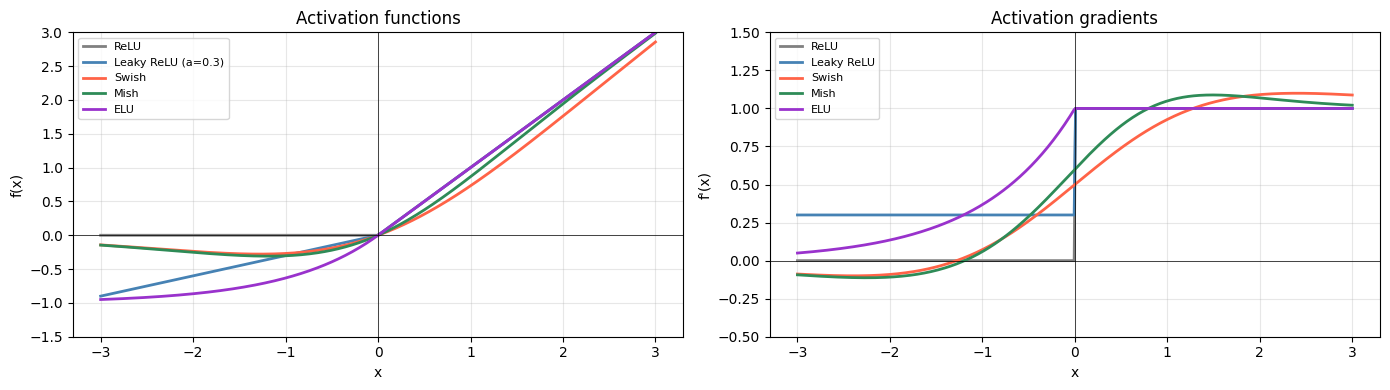

In [14]:
# --- Leaky ReLU (custom version for illustration) ---
# Fixes the dying ReLU problem: instead of outputting 0 for negative inputs,
# it outputs a small negative value (alpha * x)
def my_leaky_relu(x, alpha=0.3):
    """
    Leaky ReLU: f(x) = x if x > 0 else alpha * x
    alpha=0.3 means negative inputs produce 30% of their value.
    Fixes 'dying ReLU' where neurons get stuck at zero.
    """
    return tf.maximum(alpha * x, x)


# --- Swish (Google Brain, 2017) ---
# f(x) = x * sigmoid(x)
# Smooth, non-monotonic. Outperforms ReLU on deep networks.
# Built into TF as tf.nn.swish but we implement it to show the formula.
def my_swish(x):
    """
    Swish: f(x) = x * sigmoid(x)
    Smooth everywhere (no kink at 0 like ReLU).
    Non-monotonic: slight dip below 0 for x near -1.
    """
    return x * tf.sigmoid(x)


# --- Mish (Misra, 2019) ---
# f(x) = x * tanh(softplus(x))
# Similar to Swish but with stronger self-regularization.
def my_mish(x):
    """
    Mish: f(x) = x * tanh(softplus(x))
    softplus(x) = log(1 + exp(x)) — smooth approximation of ReLU
    Mish is bounded below (won't explode negative) and unbounded above.
    """
    return x * tf.tanh(tf.math.softplus(x))


# --- Parametric ReLU (learnable alpha) ---
class PReLU(tf.keras.layers.Layer):
    """
    Parametric ReLU: alpha is a learned parameter per neuron.
    Unlike Leaky ReLU (fixed alpha), PReLU learns the negative slope.
    Each output neuron gets its own alpha, initialized to 0.25.
    """
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        # One alpha per feature dimension (not per sample)
        self.alpha = self.add_weight(
            name='alpha',
            shape=(input_shape[-1],),
            initializer=tf.initializers.Constant(0.25),
            trainable=True
        )

    def call(self, inputs):
        return tf.maximum(self.alpha * inputs, inputs)

    def get_config(self):
        return super().get_config()


# Visualise all activations
x_range = np.linspace(-3, 3, 400).astype(np.float32)
x_tf    = tf.constant(x_range)

activations = {
    'ReLU':       tf.nn.relu(x_tf).numpy(),
    'Leaky ReLU (a=0.3)': my_leaky_relu(x_tf, alpha=0.3).numpy(),
    'Swish':      my_swish(x_tf).numpy(),
    'Mish':       my_mish(x_tf).numpy(),
    'ELU':        tf.nn.elu(x_tf).numpy(),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ['grey', 'steelblue', 'tomato', 'seagreen', 'darkorchid']

for (name, vals), color in zip(activations.items(), colors):
    axes[0].plot(x_range, vals, label=name, color=color, linewidth=2)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].axvline(0, color='black', linewidth=0.5)
axes[0].set_title('Activation functions')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-1.5, 3)

# Derivatives (gradients)
x_var = tf.Variable(x_range)
grad_dict = {}
for name, fn in [('ReLU', tf.nn.relu), ('Leaky ReLU', lambda x: my_leaky_relu(x, 0.3)),
                  ('Swish', my_swish), ('Mish', my_mish), ('ELU', tf.nn.elu)]:
    with tf.GradientTape() as tape:
        y = fn(x_var)
    grad_dict[name] = tape.gradient(y, x_var).numpy()

for (name, grads), color in zip(grad_dict.items(), colors):
    axes[1].plot(x_range, grads, label=name, color=color, linewidth=2)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].set_title('Activation gradients')
axes[1].set_xlabel('x')
axes[1].set_ylabel("f'(x)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-0.5, 1.5)

plt.tight_layout()
plt.show()

## 3. A/B Test: ReLU vs Swish vs Mish


ReLU                           -> best val acc: 0.8796
Swish (custom)                 -> best val acc: 0.8592
Mish (custom)                  -> best val acc: 0.8692
Leaky ReLU (custom)            -> best val acc: 0.8750


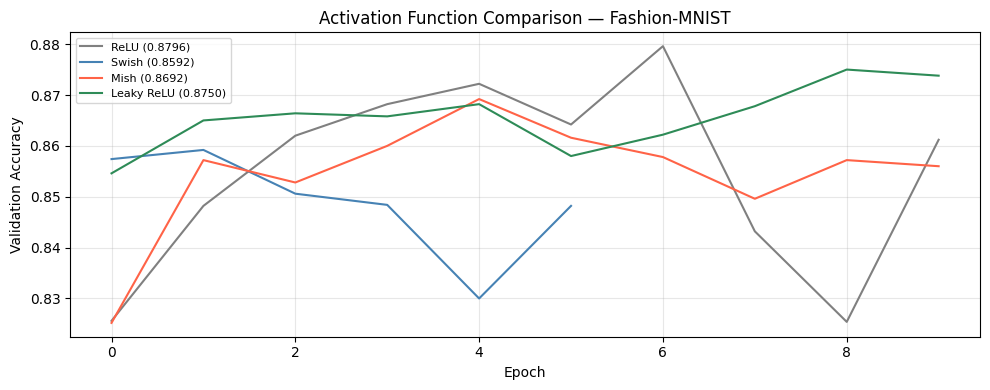

In [15]:
def make_model_with_activation(activation, name='model'):
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(300, activation=activation,
                               kernel_initializer='he_normal'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(200, activation=activation,
                               kernel_initializer='he_normal'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(100, activation=activation,
                               kernel_initializer='he_normal'),
        tf.keras.layers.Dense(10, activation='softmax'),
    ], name=name)


def train_and_get_hist(model, label, epochs=20):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    h = model.fit(
        X_train, y_train,
        validation_data=(X_valid, y_valid),
        epochs=epochs, batch_size=64,
        callbacks=[tf.keras.callbacks.EarlyStopping(
            patience=5, restore_best_weights=True)],
        verbose=0
    )
    best = max(h.history['val_accuracy'])
    print(f'{label:30s} -> best val acc: {best:.4f}')
    return h, best


tf.random.set_seed(42)
h_relu,  acc_relu  = train_and_get_hist(
    make_model_with_activation('relu'), 'ReLU')

tf.random.set_seed(42)
h_swish, acc_swish = train_and_get_hist(
    make_model_with_activation(my_swish), 'Swish (custom)')

tf.random.set_seed(42)
h_mish,  acc_mish  = train_and_get_hist(
    make_model_with_activation(my_mish), 'Mish (custom)')

tf.random.set_seed(42)
h_lrelu, acc_lrelu = train_and_get_hist(
    make_model_with_activation(my_leaky_relu), 'Leaky ReLU (custom)')

plt.figure(figsize=(10, 4))
for hist, label, color, acc in [
    (h_relu,  'ReLU',         'grey',       acc_relu),
    (h_swish, 'Swish',        'steelblue',  acc_swish),
    (h_mish,  'Mish',         'tomato',     acc_mish),
    (h_lrelu, 'Leaky ReLU',   'seagreen',   acc_lrelu),
]:
    plt.plot(hist.history['val_accuracy'], color=color,
             label=f'{label} ({acc:.4f})', linewidth=1.5)
plt.title('Activation Function Comparison — Fashion-MNIST')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Custom Weight Initializers

Initializers in Keras are callables: `f(shape, dtype) -> tensor`.
You can pass any such function as `kernel_initializer=my_init`.


Custom initializer verification (shape 256x128):
  Glorot — expected std: 0.07217, actual std: 0.07189
  He     — expected std: 0.08839, actual std: 0.08832


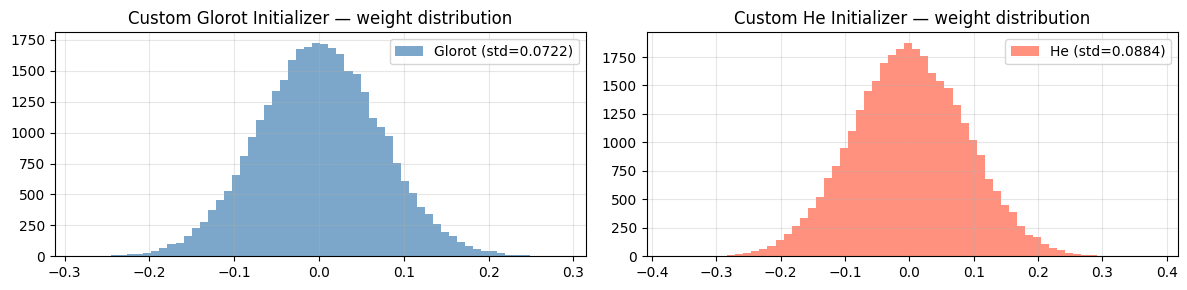

In [16]:
class MyGlorotInitializer(tf.keras.initializers.Initializer):
    """
    Custom Glorot (Xavier) Normal initializer.
    std = sqrt(2 / (fan_in + fan_out))

    We implement it from scratch to show:
    1. How to compute fan_in and fan_out from the shape
    2. The formula itself
    3. The get_config pattern for serialization
    """
    def __call__(self, shape, dtype=tf.float32):
        fan_in  = shape[0] if len(shape) >= 1 else 1
        fan_out = shape[1] if len(shape) >= 2 else 1
        std     = tf.sqrt(2.0 / (fan_in + fan_out))
        return tf.random.normal(shape, stddev=std, dtype=dtype)

    def get_config(self):
        return {}  # no hyperparameters to save


class MyHeInitializer(tf.keras.initializers.Initializer):
    """
    Custom He (Kaiming) Normal initializer.
    std = sqrt(2 / fan_in)
    Designed for ReLU — accounts for ReLU zeroing half its inputs.
    """
    def __call__(self, shape, dtype=tf.float32):
        fan_in = shape[0] if len(shape) >= 1 else 1
        std    = tf.sqrt(2.0 / fan_in)
        return tf.random.normal(shape, stddev=std, dtype=dtype)

    def get_config(self):
        return {}


# Verify the initializers produce the expected standard deviations
shape = (256, 128)  # typical Dense layer: 256 inputs, 128 outputs
fan_in, fan_out = shape

glorot_w = MyGlorotInitializer()(shape)
he_w     = MyHeInitializer()(shape)

glorot_expected_std = np.sqrt(2.0 / (fan_in + fan_out))
he_expected_std     = np.sqrt(2.0 / fan_in)

print('Custom initializer verification (shape 256x128):')
print(f'  Glorot — expected std: {glorot_expected_std:.5f}, '
      f'actual std: {tf.math.reduce_std(glorot_w).numpy():.5f}')
print(f'  He     — expected std: {he_expected_std:.5f}, '
      f'actual std: {tf.math.reduce_std(he_w).numpy():.5f}')

# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].hist(glorot_w.numpy().flatten(), bins=60,
             color='steelblue', alpha=0.7,
             label=f'Glorot (std={glorot_expected_std:.4f})')
axes[0].set_title('Custom Glorot Initializer — weight distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(he_w.numpy().flatten(), bins=60,
             color='tomato', alpha=0.7,
             label=f'He (std={he_expected_std:.4f})')
axes[1].set_title('Custom He Initializer — weight distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Custom Regularizers

Regularizers are callables: `f(weights) -> scalar penalty`.
Subclass `tf.keras.regularizers.Regularizer` and implement `__call__`.


In [17]:
class MyL1Regularizer(tf.keras.regularizers.Regularizer):
    """
    L1 regularization: penalty = l1 * sum(|w|)
    Encourages sparse weight matrices — many weights become exactly zero.
    """
    def __init__(self, l1=0.001):
        self.l1 = l1

    def __call__(self, weights):
        return self.l1 * tf.reduce_sum(tf.abs(weights))

    def get_config(self):
        return {'l1': self.l1}


class MyElasticNetRegularizer(tf.keras.regularizers.Regularizer):
    """
    ElasticNet: combines L1 (sparsity) + L2 (smooth shrinkage).
    penalty = l1 * sum(|w|) + l2 * sum(w^2)
    """
    def __init__(self, l1=0.001, l2=0.001):
        self.l1 = l1
        self.l2 = l2

    def __call__(self, weights):
        l1_penalty = self.l1 * tf.reduce_sum(tf.abs(weights))
        l2_penalty = self.l2 * tf.reduce_sum(tf.square(weights))
        return l1_penalty + l2_penalty

    def get_config(self):
        return {'l1': self.l1, 'l2': self.l2}


# Verify on a dummy weight tensor
w = tf.constant([[1.0, -2.0, 0.5, 0.0], [-0.3, 1.5, -0.8, 0.2]])

l1_reg  = MyL1Regularizer(l1=0.01)
en_reg  = MyElasticNetRegularizer(l1=0.005, l2=0.005)

print('Custom regularizer verification:')
print(f'  Weights: {w.numpy()}')
print(f'  L1 penalty  (l1=0.01) : {l1_reg(w).numpy():.6f}')
print(f'  ElasticNet  (l1=l2=0.005): {en_reg(w).numpy():.6f}')

# Manual check
w_np    = w.numpy()
l1_man  = 0.01 * np.abs(w_np).sum()
en_man  = 0.005 * np.abs(w_np).sum() + 0.005 * (w_np**2).sum()
print(f'  Manual L1  : {l1_man:.6f}  match={np.isclose(l1_reg(w).numpy(), l1_man)}')
print(f'  Manual EN  : {en_man:.6f}  match={np.isclose(en_reg(w).numpy(), en_man)}')

Custom regularizer verification:
  Weights: [[ 1.  -2.   0.5  0. ]
 [-0.3  1.5 -0.8  0.2]]
  L1 penalty  (l1=0.01) : 0.063000
  ElasticNet  (l1=l2=0.005): 0.072850
  Manual L1  : 0.063000  match=True
  Manual EN  : 0.072850  match=True


## 6. Custom Kernel Constraints

Constraints are applied POST-UPDATE — after each gradient step,
the constraint clips or projects the weights to satisfy a condition.
Unlike regularizers (soft penalties), constraints are hard limits.


In [18]:
class MyPositiveWeights(tf.keras.constraints.Constraint):
    """
    Constraint: all weights must be non-negative.
    After each update, negative weights are clipped to 0.

    Useful for:
    - Monotonic models (input increasing -> output increasing)
    - Non-negative matrix factorization
    - Certain probability distribution models
    """
    def __call__(self, w):
        return tf.nn.relu(w)  # clip(w, 0, inf)

    def get_config(self):
        return {}


class UnitNormConstraint(tf.keras.constraints.Constraint):
    """
    Constraint: each weight COLUMN has unit L2 norm.
    Normalizes each column to lie on the unit sphere.

    Useful for:
    - Word embedding layers (keeps embeddings comparable)
    - Metric learning (cosine similarity architectures)
    """
    def __call__(self, w):
        # Compute L2 norm of each column, then divide
        norms = tf.norm(w, axis=0, keepdims=True)  # shape (1, n_units)
        return w / (norms + 1e-8)

    def get_config(self):
        return {}


# Verify constraints
test_w = tf.constant([[-1.0, 2.0], [0.5, -3.0], [1.5, 0.0]])
print('Original weights:')
print(test_w.numpy())

pos_w = MyPositiveWeights()(test_w)
print('\nAfter MyPositiveWeights (no negatives):')
print(pos_w.numpy())

unit_w = UnitNormConstraint()(test_w)
col_norms = tf.norm(unit_w, axis=0).numpy()
print('\nAfter UnitNormConstraint (each column has norm=1):')
print(unit_w.numpy())
print(f'Column norms: {col_norms.round(4)} (should all be 1.0)')

Original weights:
[[-1.   2. ]
 [ 0.5 -3. ]
 [ 1.5  0. ]]

After MyPositiveWeights (no negatives):
[[0.  2. ]
 [0.5 0. ]
 [1.5 0. ]]

After UnitNormConstraint (each column has norm=1):
[[-0.5345225   0.5547002 ]
 [ 0.26726124 -0.8320503 ]
 [ 0.80178374  0.        ]]
Column norms: [1. 1.] (should all be 1.0)


## 7. Model Using ALL Four Custom Components


Standard (built-in components) -> best val acc: 0.8686
Custom (Swish+HeInit+ElasticNet+MaxNorm) -> best val acc: 0.8622


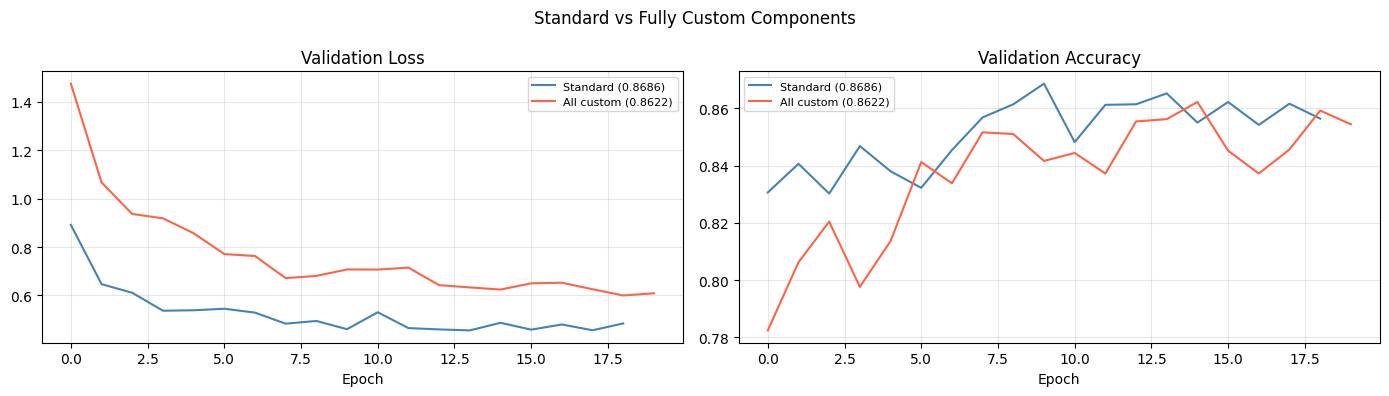

In [19]:
def make_fully_custom_model():
    """
    A model that uses:
    - Custom activation (Swish)
    - Custom initializer (He Normal from scratch)
    - Custom regularizer (ElasticNet)
    - Custom constraint (MaxNorm via built-in, to show constraint slot)
    """
    reg = MyElasticNetRegularizer(l1=0.0002, l2=0.001)

    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),

        tf.keras.layers.Dense(
            300,
            activation=my_swish,                  # custom activation
            kernel_initializer=MyHeInitializer(), # custom initializer
            kernel_regularizer=reg,               # custom regularizer
            kernel_constraint=tf.keras.constraints.MaxNorm(2.0)  # constraint
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Dense(
            200,
            activation=my_swish,
            kernel_initializer=MyHeInitializer(),
            kernel_regularizer=reg,
            kernel_constraint=tf.keras.constraints.MaxNorm(2.0)
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Dense(
            100,
            activation=my_swish,
            kernel_initializer=MyHeInitializer(),
            kernel_regularizer=MyL1Regularizer(l1=0.0001),
        ),
        tf.keras.layers.Dense(10, activation='softmax'),
    ])


def make_standard_model():
    """Standard model with built-in components for comparison."""
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(300, activation='relu',
                               kernel_initializer='he_normal',
                               kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        tf.keras.layers.BatchNormalization(), tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(200, activation='relu',
                               kernel_initializer='he_normal',
                               kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        tf.keras.layers.BatchNormalization(), tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(100, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax'),
    ])


tf.random.set_seed(42)
h_std, acc_std = train_and_get_hist(make_standard_model(),
                                    'Standard (built-in components)')

tf.random.set_seed(42)
h_cust, acc_cust = train_and_get_hist(make_fully_custom_model(),
                                      'Custom (Swish+HeInit+ElasticNet+MaxNorm)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric, title in zip(axes, ['loss', 'accuracy'], ['Loss', 'Accuracy']):
    ax.plot(h_std.history[f'val_{metric}'],  color='steelblue',
            label=f'Standard ({acc_std:.4f})')
    ax.plot(h_cust.history[f'val_{metric}'], color='tomato',
            label=f'All custom ({acc_cust:.4f})')
    ax.set_title(f'Validation {title}')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle('Standard vs Fully Custom Components', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Save and Reload with Custom Components


In [20]:
tf.random.set_seed(42)
save_model = make_fully_custom_model()
save_model.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
save_model.fit(X_train, y_train, epochs=3, batch_size=64, verbose=0)

save_model.save('/tmp/fully_custom_model.keras')
print('Model saved.')

# All custom components must be in custom_objects
custom_objects = {
    'my_swish':                 my_swish,
    'MyHeInitializer':          MyHeInitializer,
    'MyElasticNetRegularizer':  MyElasticNetRegularizer,
    'MyL1Regularizer':          MyL1Regularizer,
    'PReLU':                    PReLU,
    'MyPositiveWeights':        MyPositiveWeights,
    'UnitNormConstraint':       UnitNormConstraint,
}

loaded = tf.keras.models.load_model(
    '/tmp/fully_custom_model.keras',
    custom_objects=custom_objects
)
print('Model loaded successfully.')

orig_pred   = save_model.predict(X_test[:10], verbose=0)
loaded_pred = loaded.predict(X_test[:10], verbose=0)
max_diff    = np.abs(orig_pred - loaded_pred).max()
print(f'Max prediction difference after save/load: {max_diff:.2e}  (expect ~0)')

Model saved.
Model loaded successfully.
Max prediction difference after save/load: 0.00e+00  (expect ~0)


---
## Part B — PyTorch

## 9. Custom Components in PyTorch


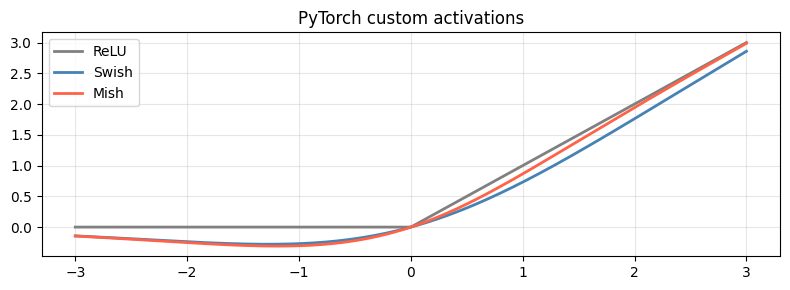

Custom Glorot init — expected std: 0.07217, actual: 0.07275


In [21]:
# --- Custom activations as functions ---
def swish_pt(x):  return x * torch.sigmoid(x)
def mish_pt(x):   return x * torch.tanh(torch.nn.functional.softplus(x))


# --- Custom activation as nn.Module (for use in nn.Sequential) ---
class Swish(nn.Module):
    def forward(self, x): return x * torch.sigmoid(x)

class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(torch.nn.functional.softplus(x))

class PReLUCustom(nn.Module):
    """Parametric ReLU with learned alpha per feature."""
    def __init__(self, num_features):
        super().__init__()
        self.alpha = nn.Parameter(torch.full((num_features,), 0.25))

    def forward(self, x):
        return torch.maximum(self.alpha * x, x)


# --- Custom initializer function ---
def my_glorot_init_(tensor):
    """
    Apply Glorot Normal initialization in-place.
    Usage: my_glorot_init_(layer.weight)
    """
    fan_in, fan_out = nn.init._calculate_fan_in_and_fan_out(tensor)
    std = (2.0 / (fan_in + fan_out)) ** 0.5
    with torch.no_grad():
        tensor.normal_(0, std)
    return tensor


# --- Custom L1 regularizer function ---
def l1_penalty(model, l1=0.001):
    """Add to loss before backward()."""
    penalty = torch.tensor(0.0, device=next(model.parameters()).device)
    for name, param in model.named_parameters():
        if 'weight' in name:
            penalty += l1 * param.abs().sum()
    return penalty


# --- Custom positive-weights constraint ---
def apply_positive_weights_(model):
    """Clip all weights to be non-negative. Call after optimizer.step()."""
    with torch.no_grad():
        for name, param in model.named_parameters():
            if 'weight' in name:
                param.clamp_(min=0.0)


# Test custom activations
x_pt   = torch.linspace(-3, 3, 400)
relu   = torch.relu(x_pt).numpy()
swish  = swish_pt(x_pt).detach().numpy()
mish   = mish_pt(x_pt).detach().numpy()

plt.figure(figsize=(8, 3))
plt.plot(x_pt.numpy(), relu,  color='grey',      label='ReLU',  linewidth=2)
plt.plot(x_pt.numpy(), swish, color='steelblue', label='Swish', linewidth=2)
plt.plot(x_pt.numpy(), mish,  color='tomato',    label='Mish',  linewidth=2)
plt.title('PyTorch custom activations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Verify custom initializer
test_layer = nn.Linear(256, 128)
my_glorot_init_(test_layer.weight)
expected_std = (2.0 / (256 + 128)) ** 0.5
actual_std   = test_layer.weight.data.std().item()
print(f'Custom Glorot init — expected std: {expected_std:.5f}, actual: {actual_std:.5f}')

## 10. PyTorch Model with Custom Components + A/B Test


Training ReLU baseline...
[ReLU baseline] Epoch  5 | val=0.8788
[ReLU baseline] Epoch 10 | val=0.8892
[ReLU baseline] Epoch 15 | val=0.8900
[ReLU baseline] Epoch 20 | val=0.8864
[ReLU baseline] Best val acc: 0.8920

Training Swish + custom init + L1...
[Swish+GlorotInit+L1] Epoch  5 | val=0.8582
[Swish+GlorotInit+L1] Epoch 10 | val=0.8540
[Swish+GlorotInit+L1] Epoch 15 | val=0.8638
[Swish+GlorotInit+L1] Epoch 20 | val=0.8630
[Swish+GlorotInit+L1] Best val acc: 0.8728

Training Mish + custom init + L1...
[Mish+GlorotInit+L1] Epoch  5 | val=0.8624
[Mish+GlorotInit+L1] Epoch 10 | val=0.8578
[Mish+GlorotInit+L1] Epoch 15 | val=0.8666
[Mish+GlorotInit+L1] Epoch 20 | val=0.8682
[Mish+GlorotInit+L1] Best val acc: 0.8716



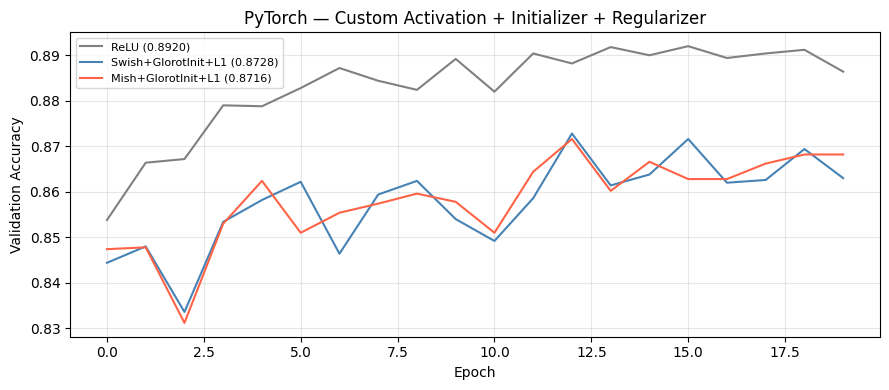

In [11]:
class CustomNet(nn.Module):
    """Network using custom activation, initializer, and regularizer."""
    def __init__(self, activation_cls=Swish):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 300), nn.BatchNorm1d(300), activation_cls(), nn.Dropout(0.3),
            nn.Linear(300, 200), nn.BatchNorm1d(200), activation_cls(), nn.Dropout(0.3),
            nn.Linear(200, 100), nn.BatchNorm1d(100), activation_cls(),
            nn.Linear(100, 10)
        )
        # Apply custom Glorot initializer to all Linear layers
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                my_glorot_init_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x): return self.net(x)


def train_pt(model_factory, label, epochs=20, use_l1=False):
    torch.manual_seed(42)
    model     = model_factory().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    best_acc  = 0.0
    hist_val  = []

    for epoch in range(epochs):
        model.train()
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            if use_l1:
                loss = loss + l1_penalty(model, l1=0.0001)
            loss.backward()
            optimizer.step()

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for X_b, y_b in valid_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                correct += (model(X_b).argmax(1) == y_b).sum().item()
                total   += y_b.size(0)
        val_acc  = correct / total
        best_acc = max(best_acc, val_acc)
        hist_val.append(val_acc)

        if (epoch + 1) % 5 == 0:
            print(f'[{label}] Epoch {epoch+1:2d} | val={val_acc:.4f}')

    print(f'[{label}] Best val acc: {best_acc:.4f}\n')
    return hist_val, best_acc


print('Training ReLU baseline...')
hist_relu_pt, acc_relu_pt = train_pt(
    lambda: CustomNet(nn.ReLU), 'ReLU baseline', epochs=20
)
print('Training Swish + custom init + L1...')
hist_swish_pt, acc_swish_pt = train_pt(
    lambda: CustomNet(Swish), 'Swish+GlorotInit+L1', epochs=20, use_l1=True
)
print('Training Mish + custom init + L1...')
hist_mish_pt, acc_mish_pt = train_pt(
    lambda: CustomNet(Mish), 'Mish+GlorotInit+L1', epochs=20, use_l1=True
)

plt.figure(figsize=(9, 4))
plt.plot(hist_relu_pt,  color='grey',      label=f'ReLU ({acc_relu_pt:.4f})')
plt.plot(hist_swish_pt, color='steelblue', label=f'Swish+GlorotInit+L1 ({acc_swish_pt:.4f})')
plt.plot(hist_mish_pt,  color='tomato',    label=f'Mish+GlorotInit+L1 ({acc_mish_pt:.4f})')
plt.title('PyTorch — Custom Activation + Initializer + Regularizer')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary

### Four Component Types at a Glance

| Component | TF pattern | PyTorch pattern | Applied when |
|---|---|---|---|
| Activation | Function `f(x)->x` or `Layer.call` | Function or `nn.Module.forward` | Forward pass |
| Initializer | `Initializer.__call__(shape, dtype)` | `init_fn_(tensor)` in-place | Model creation |
| Regularizer | `Regularizer.__call__(weights)->scalar` | `penalty_fn(model)->scalar` added to loss | Training |
| Constraint | `Constraint.__call__(w)->w` | `clamp_/clip_` after `optimizer.step()` | Post-update |

### Keras Layer Constructor Slots
```python
tf.keras.layers.Dense(
    units,
    activation=my_activation,              # fn or layer
    kernel_initializer=MyInitializer(),    # Initializer subclass
    kernel_regularizer=MyRegularizer(),    # Regularizer subclass
    kernel_constraint=MyConstraint(),      # Constraint subclass
)
```

### When to reach for each
- **Custom activation**: when ReLU/SELU/Swish don't fit your architecture (e.g. non-monotonic, learnable slope)
- **Custom initializer**: when you need exact control over initial weight scale or distribution
- **Custom regularizer**: when L1/L2 alone is insufficient (e.g. orthogonality, group sparsity)
- **Custom constraint**: when you need a hard guarantee on weight values (e.g. non-negative, unit norm, bounded)

**Next: Notebook 20** — Custom Layers (ExponentialLayer, MyDense, AddGaussianNoise)
